# **IMPORT PACKAGES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import os

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


ModuleNotFoundError: No module named 'numpy'

# **EDA**

In [3]:
path = os.listdir(r'C:\Users\VASANTH\Desktop\shipi\train')
classes = {'Normal':0, 'Lung cancer':1}

# **TRAINING DATASET**

In [3]:
import cv2
X = []
Y = []
for cls in classes:
    pth = r'C:\Users\VASANTH\Desktop\shipi\train'+cls
    for j in os.listdir(pth):
        img = cv2.imread(pth+'/'+j, 0)
        img = cv2.resize(img, (200,200))
        X.append(img)
        Y.append(classes[cls])
X = np.array(X)
Y = np.array(Y)

((492, 40000), (123, 40000))

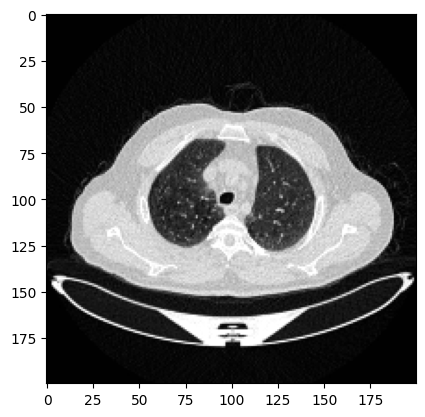

In [4]:
X_updated = X.reshape(len(X), -1)
np.unique(Y)
pd.Series(Y).value_counts()
X.shape, X_updated.shape
plt.imshow(X[0], cmap='gray')
X_updated = X.reshape(len(X), -1)
X_updated.shape
xtrain, xtest, ytrain, ytest = train_test_split(X_updated, Y, random_state=10, test_size=.20)
xtrain.shape, xtest.shape

In [5]:
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())
xtrain = xtrain/255
xtest = xtest/255
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())

255 0
255 0
1.0 0.0
1.0 0.0


In [6]:
from sklearn.decomposition import PCA

print(xtrain.shape, xtest.shape)

pca = PCA(.98)
# pca_train = pca.fit_transform(xtrain)
# pca_test = pca.transform(xtest)
pca_train = xtrain
pca_test = xtest

(492, 40000) (123, 40000)


# Ignore warnings

In [7]:
import warnings
warnings.filterwarnings('ignore')

# Initialize and train logistic regression model

In [8]:
lg = LogisticRegression(C=0.1)
lg.fit(xtrain, ytrain)

sv = SVC()
sv.fit(xtrain, ytrain)

SVC()

# Initialize and train support vector machine model

In [9]:
sv = SVC()
sv.fit(xtrain, ytrain)

SVC()

# Print training and testing scores for logistic regression model

In [10]:
print("Logistic Regression:")
print("Training Score:", lg.score(xtrain, ytrain))
print("Testing Score:", lg.score(xtest, ytest))

Logistic Regression:
Training Score: 1.0
Testing Score: 0.991869918699187


# Print training and testing scores for support vector machine model

In [11]:
print("\nSupport Vector Machine:")
print("Training Score:", sv.score(xtrain, ytrain))
print("Testing Score:", sv.score(xtest, ytest))


Support Vector Machine:
Training Score: 1.0
Testing Score: 0.991869918699187


# Make predictions using support vector machine model

In [12]:
pred = sv.predict(xtest)

# Find misclassified samples

In [13]:
misclassified = np.where(ytest != pred)

# Print total misclassified samples

In [14]:
print("\nTotal Misclassified Samples: ", len(misclassified[0]))
print("Prediction for the 36th sample:", pred[36])
print("Actual label for the 36th sample:", ytest[36])


Total Misclassified Samples:  1
Prediction for the 36th sample: 1
Actual label for the 36th sample: 1


# Define a dictionary for decoding labels

In [15]:
dec = {0: 'Normal', 1: 'Lung cancer'}

# Plotting 1

In [16]:
plt.figure(figsize=(12, 8))
p = os.listdir(r'd:\shipi\Testing/')
c = 1

<Figure size 1200x800 with 0 Axes>

# Visualizing Predictions on Normal  Images

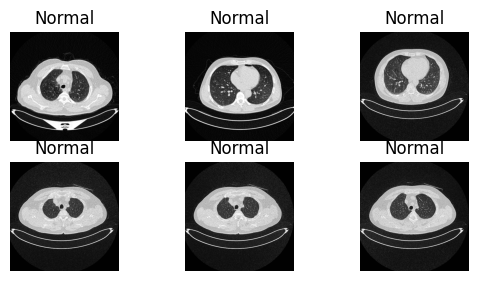

In [18]:
for i in os.listdir(r'd:\shipi\Testing\Normal/')[:6]:
    plt.subplot(3,3,c)

    img = cv2.imread(r'd:\shipi\Testing\Normal/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = sv.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1

# Plotting 2

In [19]:
plt.figure(figsize=(12,8))
p = os.listdir(r'd:\shipi\Testing/')
c=1


<Figure size 1200x800 with 0 Axes>

# Visualizing Predictions on Cancer Images

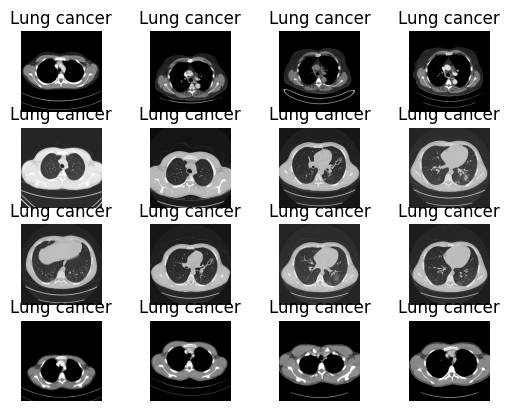

In [20]:
for i in os.listdir(r'd:\shipi\Testing\Lung cancer/')[:16]:
    plt.subplot(4,4,c)

    img = cv2.imread(r'd:\shipi\Testing\Lung cancer/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = sv.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1


# **FINDING FOR NEW IMAGE**

In [27]:
def classify_single_image(image_path, model):
    img = cv2.imread(image_path, 0)
    img = cv2.resize(img, (200, 200))
    img_processed = img.reshape(1, -1) / 255
    prediction = model.predict(img_processed)
    if prediction[0] == 0:
        return 'Normal'
    else:
        return 'Lung cancer'

In [28]:
sv = SVC()
sv.fit(xtrain, ytrain)

SVC()

In [32]:
image_path = r'D:\shipi\ownInput\tobeFind2.JPG'
prediction = classify_single_image(image_path, sv)
print("Prediction for", image_path, ":", prediction)

Prediction for D:\shipi\ownInput\tobeFind2.JPG : Lung cancer
